In [20]:
from collections import defaultdict, Counter
import random
from IPython.display import clear_output
import glob 
import json

import numpy as np
import re

import matplotlib.pyplot as plt

class ISISequence:
    def __init__(self, length=252, isi_values=[0, 1, 2, 3], seed=15):
        self.length = length
        # sequences with specific guarantees (50% repetition rate, etc), we need to enforce that the length 
        # is divisible by 3
        assert self.length % 3 == 0, "Warning: Sequence length needs to be divisible by 3"
        # ideally, the sequence length should also be a multiple of 3 and the number of positive ISIs
        
        self.isi_values = isi_values
        self.seed = seed
        self.sequences = []
        self.pairs = []
        self._rng = random.Random(seed)
        self._seen_sequences = set()
        self.debug = False

    def toggle_debug(self):
        self.debug = not self.debug

        print(f"Debug switch now turned {self.debug}!")

    def generate_one(self, target_repetition_rate=0.5, min_pairs_per_isi=2):

        from collections import defaultdict

        # functions useful for Step 3: Try to upgrade non-repeats to hit the target repetition rate
        def find_upgradeable_pairs(isi_key, isi_value):
            upgrades = []
            for i in range(len(isi_key) - isi_value - 1):
                j = i + isi_value + 1
                if isi_key[i] == -1 and isi_key[j] == -1:
                    upgrades.append((i, j))
            return upgrades

        def count_nonrepeats(isi_key):
            return sum(1 for x in isi_key if x == -1)

        def count_repeats(isi_key):
            return sum(1 for x in isi_key if x >= 0) // 2

        def current_repetition_rate(num_repeats, num_nonrepeats):
            return num_repeats / (num_repeats + num_nonrepeats) 
        
        good_sequence = False
        desired_num_pairs = self.length // 3 
    
        while not good_sequence:
            
            i = 0

            isi_key = [-2] * self.length
            pairs_by_isi = defaultdict(list)
            pos_isi_values = [isi for isi in self.isi_values if isi >= 0]

            if self.debug:
                print("Before shuffling the ISIs")
                print(pos_isi_values)
            
            self._rng.shuffle(pos_isi_values)

            if self.debug:
                print("After shuffling the ISIs")
                print(pos_isi_values)
            
            isi_index = 0
            repeat_pairs_inserted = 0
    
            # Step 1: Insert as many repeat pairs as possible (with no regards to the desired number of pairs) 
            while i < self.length: #and repeat_pairs_inserted < desired_num_pairs:
                isi = pos_isi_values[isi_index % len(pos_isi_values)]
                isi_index += 1
    
                if i + isi + 1 < self.length and isi_key[i] == -2 and isi_key[i + isi + 1] == -2:
                    isi_key[i] = isi
                    isi_key[i + isi + 1] = isi
                    pairs_by_isi[isi].append((i, i + isi + 1))
                    repeat_pairs_inserted += 1
                    i += 1

                    if self.debug:
                        print(f"inserted isi of {isi} at trial {i} and {i + isi + 1}")
                else:
                    i += 1
                    if self.debug:
                        print(f"inserting isi of {isi} at trial {i} and {i + isi + 1} was not successful")

                #i = i % self.length
    
            # Step 2: Fill remaining slots as non-repeats
            for idx, val in enumerate(isi_key):
                if val == -2:
                    isi_key[idx] = -1
            
            # Step 3: Try to upgrade non-repeats to hit the target repetition rate
            # get the current rep rate
            num_nonrepeats = count_nonrepeats(isi_key)
            num_repeats    = count_repeats(isi_key)
            
            current_rate   = current_repetition_rate(num_repeats, num_nonrepeats)

            while not current_rate == target_repetition_rate:
    
                if current_rate < target_repetition_rate:
    
                    if self.debug:
                       print(f"Current repetition rate {current_rate}")
                    
                    #clear_output(wait=False)
                    #continue
                    self._rng.shuffle(pos_isi_values)
        
                    #while not current_rate == target_repetition_rate:
                    isi = pos_isi_values[isi_index % len(pos_isi_values)]
                    isi_index += 1
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    
                    if len(upgrade_candidates) > 0:
    
                        # Upgrade this pair
                        i1, i2 = upgrade_candidates[-1]
                            
                        isi_key[i1] = isi
                        isi_key[i2] = isi
                        pairs_by_isi[isi].append((i1, i2))
                        repeat_pairs_inserted += 1

                        if self.debug:
                           print(f"Added ({i1}, {i2})")
                        
                        # check the current repetition rate
                        num_nonrepeats = count_nonrepeats(isi_key)
                        num_repeats    = count_repeats(isi_key)
                        current_rate   = current_repetition_rate(num_repeats, num_nonrepeats)
                    
                    if self.debug:
                        print(f" Rep. Rate after additions = {current_rate}")
    
                elif current_rate > target_repetition_rate:
    
                    if self.debug:
                       print(f"Current repetition rate {current_rate}")
                        
                    # GOAL: 
                    # we want to remove pairs until we get to the target reptition rate
                    # particularly the ones that are overrepresented (so if one ISI has a lot of representation in 'pairs_by_isi', i'd like to randomly replace one of those
                    # trials with two non-repeat trials 
                    
                    # Compute how many repeat pairs to remove
                    num_nonrepeats = count_nonrepeats(isi_key)
                    num_repeats = count_repeats(isi_key)
                    excess = num_repeats - int(target_repetition_rate * (num_repeats + num_nonrepeats))
                
                    # Flatten all pairs
                    all_pairs = [(isi, pair) for isi, pairs in pairs_by_isi.items() for pair in pairs]
                    # Sort by overrepresentation
                    all_pairs.sort(key=lambda x: -len(pairs_by_isi[x[0]]))
                    self._rng.shuffle(all_pairs)  # Optional: add noise to avoid bias
                
                    removed = 0
                    for isi, (i1, i2) in all_pairs:
                        if removed >= excess:
                            break
                        if isi_key[i1] == isi and isi_key[i2] == isi:
                            isi_key[i1] = -1
                            isi_key[i2] = -1
                            pairs_by_isi[isi].remove((i1, i2))
                            removed += 1
                            if self.debug:
                               print(f"Removed ({i1}, {i2}).")
                
                    # Recompute rate
                    num_nonrepeats = count_nonrepeats(isi_key)
                    num_repeats = count_repeats(isi_key)
                    current_rate = current_repetition_rate(num_repeats, num_nonrepeats)
                    if self.debug:
                        print(f" Rep. Rate after removals = {current_rate}")


            # Step 3a: Try to add more repeat pairs to underrepresented ISIs
            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) < min_pairs_per_isi:
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    if not upgrade_candidates:
                        if self.debug:
                            print(f"⚠️ No more upgradeable pairs available for ISI {isi}")
                        break  # can't add more to this ISI
            
                    i1, i2 = upgrade_candidates.pop()
                    isi_key[i1] = isi
                    isi_key[i2] = isi
                    pairs_by_isi[isi].append((i1, i2))
            
                    if self.debug:
                        print(f"✅ Added ({i1}, {i2}) to ISI {isi} (to reach {min_pairs_per_isi})")
            
            # Step 3b: Prune overrepresented ISIs to enforce exact per-ISI balance
            if self.debug:
                for isi in pos_isi_values:
                    print(f"# Pairs for each #IS condition {isi}: {len(pairs_by_isi[isi])}")
                          
            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) > min_pairs_per_isi:
                    self._rng.shuffle(pairs_by_isi[isi])
                    i1, i2 = pairs_by_isi[isi].pop()
                    isi_key[i1] = -1
                    isi_key[i2] = -1
                    if self.debug:
                        print(f"❌ Pruned ({i1}, {i2}) from #IS {isi} (exceeded {min_pairs_per_isi})")

            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) < min_pairs_per_isi:
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    if not upgrade_candidates:
                        if self.debug:
                            print(f"⚠️ No more upgradeable pairs available for #IS {isi}")
                        break  # can't add more to this ISI
            
                    i1, i2 = upgrade_candidates.pop()
                    isi_key[i1] = isi
                    isi_key[i2] = isi
                    pairs_by_isi[isi].append((i1, i2))
            
                    if self.debug:
                        print(f"✅ Added ({i1}, {i2}) to ISI {isi} (to reach {min_pairs_per_isi})")

            if self.debug:
                for isi in pos_isi_values:
                    print(f"# Pairs for ISI {isi}: {len(pairs_by_isi[isi])}")
            

            num_nonrepeats = count_nonrepeats(isi_key)
            num_repeats = count_repeats(isi_key)
            current_rate = current_repetition_rate(num_repeats, num_nonrepeats)

            if self.debug:
                print(f"Final repetition rate: {current_rate}")
            
            good_sequence = all(len(pairs_by_isi[isi]) >= min_pairs_per_isi for isi in pos_isi_values)
            if not good_sequence and self.debug:
                print("⚠️ Not all ISIs met the minimum requirement. Regenerating...")
                clear_output(wait=False)

            if not good_sequence:
                clear_output(wait=False)
        
        if self.debug:
            print("CURRENT REPETITION RATE", current_rate)
            print("AFTER:")
            print(isi_key)
            print(pairs_by_isi)
            
        #self.sequences.append(isi_key)
        seq_tuple = tuple(isi_key)
        if seq_tuple not in self._seen_sequences:
            self._seen_sequences.add(seq_tuple)
            self.sequences.append(isi_key)

            for key in pairs_by_isi:
                pairs_by_isi[key] = sorted(pairs_by_isi[key])

            for isi_key_pos, isi in enumerate(isi_key):
                if isi == -1:
                    pairs_by_isi[isi].append(isi_key_pos)

            #pairs_by_isi = sorted(pairs_by_isi)
            pairs_by_isi = {k: pairs_by_isi[k] for k in sorted(pairs_by_isi)}
                    
            self.pairs.append(pairs_by_isi)
        else:
            if self.debug:
                print("⚠️ Duplicate sequence detected. Regenerating...")
                
                
            return self.generate_one(target_repetition_rate, min_pairs_per_isi)
        return isi_key, pairs_by_isi

    def generate_n(self, n, target_repetition_rate=0.5, min_pairs_per_isi=2):
        cumulative_counts = Counter()
    
        for _ in range(n):
            self.seed += 1
            self._rng.seed(self.seed)
    
            isi_key, pairs_by_isi = self.generate_one(
                target_repetition_rate=target_repetition_rate, 
                min_pairs_per_isi=min_pairs_per_isi
            )
    
            #self.sequences.append(isi_key)  # store it
    
            for isi in isi_key:
                if isi >= 0:
                    cumulative_counts[isi] += 1
                else:
                    cumulative_counts[-1] += 1  # track nonrepeats
    
        print("Aggregate ISI usage across all sequences:")
        for isi in sorted(cumulative_counts):
            print(f"  ISI {isi}: {cumulative_counts[isi]}")

    def summary_across(self):
        combined = Counter()
        for isi_key in self.sequences:
            combined.update(Counter(isi_key))
        return dict(combined)

    def get_sequence_and_isi_pairings(self, sequence_id):
        return self.sequences[sequence_id], self.pairs[sequence_id]

    def check_balance(self, verbose=True):
        import numpy as np
    
        summary = self.summary_across()
        pos_isis = [isi for isi in self.isi_values if isi >= 0]
        counts = np.array([summary.get(isi, 0) for isi in pos_isis])
        mean_counts = np.mean(counts)
    
        if verbose:
            print("Total ISI counts across sequences:")
            for isi, count in zip(pos_isis, counts):
                print(f"ISI {isi}: {count}")
    
        mean = np.mean(counts)
        std = np.std(counts)
    
        z_scores = (counts - mean) / std if std > 0 else np.zeros_like(counts)
        max_deviation = np.max(np.abs(z_scores))
    
        if max_deviation > 1:
            print(f"⚠️ ISI imbalance detected (max z-score = {max_deviation:.2f})")
        else:
            print("✅ ISI conditions are statistically balanced (within 1 std deviation).")
        
    def clear_sequences(self):
        """Remove all stored sequences."""
        self.sequences = []

    def plot_summary(self, title="ISI Distribution Across Sequences (n={}, seq. length={})"):
        """Plot a bar chart of ISI usage across all stored sequences."""
        summary = self.summary_across()
    
        # Separate ISI values and counts
        isi_vals = sorted(summary.keys())
        counts = [summary[isi] for isi in isi_vals]
    
        # Plot
        plt.figure(figsize=(8, 5))
        plt.bar([str(isi) for isi in isi_vals], counts, alpha=0.5)
        plt.xlabel("ISI Value")
        plt.ylabel("Number of Trials")
        plt.title(title.format(len(self.sequences), self.length))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_avg_isi_across_sequences(self):
        """Plot the average ISI value (excluding -1s) across all stored sequences."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_isis = [
            np.mean([isi for isi in seq if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        valid_isi_values = [isi for isi in self.isi_values if isi >= 0]
        empirical_avg = np.mean(avg_isis)
        theoretical_avg = np.mean(valid_isi_values)
        
        plt.figure(figsize=(6, 4))
        plt.plot(avg_isis, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')        
        plt.xlabel("Sequence Index")
        plt.ylabel("Average ISI (excluding -1)")
        plt.title("Avg. ISI per Sequence")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_avg_position_of_repeats(self):
        """Plot the average position of repeated trials in each sequence."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_positions = [
            np.mean([i for i, isi in enumerate(seq) if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        theoretical_avg = np.mean(np.arange(self.length))
        empirical_avg = np.mean(avg_positions)

        plt.figure(figsize=(6, 4))
        plt.plot(avg_positions, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')

        plt.xlabel("Sequence Index")
        plt.ylabel("Average Position of Repeats")
        plt.title("Avg. Position of Repeat Trials")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_num_repeats_per_sequence(self):
        """Plot the number of repeated stimuli (pairs) per sequence."""
        import matplotlib.pyplot as plt
    
        num_repeats = [sum(isi >= 0 for isi in seq) // 2 for seq in self.sequences]
    
        plt.figure(figsize=(6, 4))
        plt.plot(num_repeats, marker='o')
        plt.xlabel("Sequence Index")
        plt.ylabel("Number of Repeat Stimuli")
        plt.title("Number of Repeats per Sequence")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_isi_position_bias(self, bins=4):
        """
        Visualize ISI distributions across positions in the sequence to detect ISI-specific biases.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize to get proportions
        totals = np.sum(list(counts.values()), axis=0)
        proportions = {isi: counts[isi] / (totals + 1e-9) for isi in isi_labels}
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        # Add ideal reference line
        ideal_proportion = 1 / len(isi_labels)
        plt.axhline(ideal_proportion, color='gray', linestyle='--', alpha=0.7, label=f"Ideal = {ideal_proportion:.3f}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Trials")
        plt.title("Distribution of ISI Conditions Across Sequence Positions")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    def plot_repetition_rate_per_sequence(self):
        import matplotlib.pyplot as plt
    
        repetition_rates = []
        for seq in self.sequences:
            num_repeats = sum(isi >= 0 for isi in seq) // 2
            num_nonrepeats = sum(isi == -1 for isi in seq)
            total_pairs = num_repeats + num_nonrepeats
            rate = num_repeats / total_pairs
            repetition_rates.append(rate)
    
        plt.figure(figsize=(6, 4))
        plt.plot(repetition_rates, marker='o')
        plt.axhline(0.5, color='red', linestyle='--', label="Target = 0.5")
        plt.xlabel("Sequence Index")
        plt.ylabel("Repetition Rate")
        plt.title("Repetition Rate per Sequence")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_isi_temporal_spread(self, bins=5):
        """
        For each ISI, show how its trials are distributed across sequence positions (bins).
        Y-axis shows, for each ISI, what fraction of its trials fall into each bin.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        # Count how many times each ISI appears in each bin
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize by total count per ISI
        proportions = {}
        for isi in isi_labels:
            total = np.sum(counts[isi])
            if total > 0:
                proportions[isi] = counts[isi] / total
            else:
                proportions[isi] = np.zeros(bins)
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Occurrences")
        plt.title("Temporal Spread of Each ISI Across Sequence Bins")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.axhline(1/bins, color='gray', linestyle='--', alpha=0.5, label="Ideal = uniform")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def check_for_duplicate_sequences(self):
        from collections import Counter
    
        seq_tuples = [tuple(seq) for seq in self.sequences]
        counts = Counter(seq_tuples)
        duplicates = {k: v for k, v in counts.items() if v > 1}
    
        if duplicates:
            print("⚠️ Duplicate sequences found:")
            for seq, count in duplicates.items():
                print(f"  Occurs {count} times")
        else:
            print("✅ No duplicate sequences.")

def getAnswerKey(seq):
    """
    Returns a list where each position is:
    - 0 if the stimulus has not been seen before
    - 1 if the stimulus has already occurred earlier in the sequence
    """
    seen = set()
    answer_key = []

    for stim in seq:
        if stim in seen:
            answer_key.append(1)
        else:
            answer_key.append(0)
            seen.add(stim)

    return answer_key

class ISISequenceBolivia(ISISequence):
    def __init__(self, length=252, isi_counts={0: 20, 16: 22}, seed=15):
        assert sum(isi_counts.values()) * 2 <= length, "Total repeat trials exceed sequence length"
        super().__init__(length=length, isi_values=list(isi_counts.keys()), seed=seed)
        self.isi_counts = isi_counts

    def generate_one(self, target_repetition_rate=0.5, min_pairs_per_isi=0):
        def find_upgradeable_pairs(seq, isi):
            return [(i, i + isi + 1)
                    for i in range(len(seq) - isi - 1)
                    if seq[i] == -1 and seq[i + isi + 1] == -1]

        isi_key = [-1] * self.length
        pairs_by_isi = defaultdict(list)
        self._rng.shuffle(self.isi_values)

        for isi in self.isi_values:
            target_pairs = self.isi_counts[isi]
            attempts = 0
            while len(pairs_by_isi[isi]) < target_pairs:
                upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                self._rng.shuffle(upgrade_candidates)
                if not upgrade_candidates:
                    raise ValueError(f"⚠️ Could not place {target_pairs} pairs for ISI={isi} (only placed {len(pairs_by_isi[isi])})")
                i1, i2 = upgrade_candidates.pop()
                isi_key[i1] = isi
                isi_key[i2] = isi
                pairs_by_isi[isi].append((i1, i2))
                attempts += 1
                if attempts > 1000:
                    raise RuntimeError("Too many attempts to insert repeat pairs. Try increasing sequence length.")

        # Fill leftover -1s with -1 again to make explicit non-repeats
        nonrepeats = sum(1 for x in isi_key if x == -1)
        rep_pairs = sum(len(pairs_by_isi[isi]) for isi in self.isi_counts)
        nonrepeats = self.length - 2 * rep_pairs
        
        rep_rate = rep_pairs / (rep_pairs + nonrepeats)
        if abs(rep_rate - target_repetition_rate) > 0.01:
            raise ValueError(f"Actual repetition rate {rep_rate:.3f} differs from target {target_repetition_rate:.3f}")

        # Store and return
        seq_tuple = tuple(isi_key)
        if seq_tuple not in self._seen_sequences:
            self._seen_sequences.add(seq_tuple)
            self.sequences.append(isi_key)

            for key in pairs_by_isi:
                pairs_by_isi[key] = sorted(pairs_by_isi[key])

            for idx, val in enumerate(isi_key):
                if val == -1:
                    pairs_by_isi[val].append(idx)

            pairs_by_isi = {k: pairs_by_isi[k] for k in sorted(pairs_by_isi)}
            self.pairs.append(pairs_by_isi)

        return isi_key, pairs_by_isi

    def plot_summary(self, title="ISI Distribution Across Sequences (n={}, seq. length={})"):
        """Plot a bar chart of ISI usage across all stored sequences."""
        summary = self.summary_across()
    
        # Separate ISI values and counts
        isi_vals = sorted(summary.keys())
        counts = [summary[isi] for isi in isi_vals]
    
        # Plot
        plt.figure(figsize=(8, 5))
        plt.bar([str(isi) for isi in isi_vals], counts, alpha=0.5)
        plt.xlabel("ISI Value")
        plt.ylabel("Number of Trials")
        plt.title(title.format(len(self.sequences), self.length))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_avg_isi_across_sequences(self):
        """Plot the average ISI value (excluding -1s) across all stored sequences."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_isis = [
            np.mean([isi for isi in seq if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        valid_isi_values = [isi for isi in self.isi_values if isi >= 0]
        empirical_avg = np.mean(avg_isis)
        total_pairs = sum(self.isi_counts.values())
        theoretical_avg = sum(isi * count for isi, count in self.isi_counts.items()) / total_pairs        
        plt.figure(figsize=(6, 4))
        plt.plot(avg_isis, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')        
        plt.xlabel("Sequence Index")
        plt.ylabel("Average ISI (excluding -1)")
        plt.title("Avg. ISI per Sequence")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_isi_position_bias(self, bins=4):
        """
        Visualize ISI distributions across positions in the sequence to detect ISI-specific biases.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize to get proportions
        totals = np.sum(list(counts.values()), axis=0)
        proportions = {isi: counts[isi] / (totals + 1e-9) for isi in isi_labels}
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        # Add ideal reference line
        ideal_proportion = 1 / len(isi_labels)
        plt.axhline(ideal_proportion, color='gray', linestyle='--', alpha=0.7, label=f"Ideal = {ideal_proportion:.3f}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Trials")
        plt.title("Distribution of ISI Conditions Across Sequence Positions")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_isi_position_bias(self, bins=4):
        """
        Visualize ISI distributions across positions in the sequence to detect ISI-specific biases.
        Uses target proportions based on self.isi_counts instead of equal distribution.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        if not self.sequences:
            raise ValueError("No sequences available to analyze.")
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize by total counts per bin
        totals = np.sum(list(counts.values()), axis=0)
        proportions = {isi: counts[isi] / (totals + 1e-9) for isi in isi_labels}
    
        # Compute ideal proportions from self.isi_counts
        total_pairs = sum(self.isi_counts.values())
        ideal_props = {isi: self.isi_counts[isi] / total_pairs for isi in self.isi_counts}
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi} (ideal: {ideal_props[isi]:.2f})")
    
        # Add individual ideal reference lines
        for isi in isi_labels:
            plt.axhline(ideal_props[isi], linestyle='--', alpha=0.5, label=f"Ideal ISI {isi}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Trials")
        plt.title("Distribution of ISI Conditions Across Sequence Positions")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [21]:
stim_type = "global-music"

seeds_dict = {"nhs-region": 3,
             "global-music": 2,
             "atexts": 0,
             "ind-nature": 1}

In [22]:
len_exp = 120

n_exps = 200
seed = seeds_dict[stim_type]
print(seed)
sm_bolivia = ISISequenceBolivia(length=len_exp, isi_counts={0: 10, 16: 30}, seed=seed)
isi_key, pairs = sm_bolivia.generate_one(target_repetition_rate=0.5)

2


In [23]:
sm_bolivia.generate_n(n=n_exps) 

Aggregate ISI usage across all sequences:
  ISI -1: 8000
  ISI 0: 4000
  ISI 16: 12000


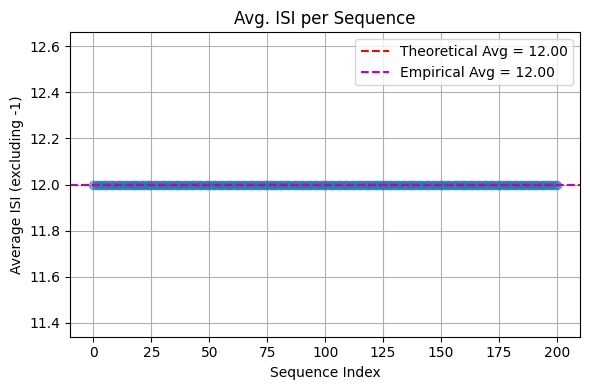

In [24]:
sm_bolivia.plot_avg_isi_across_sequences() # to edit

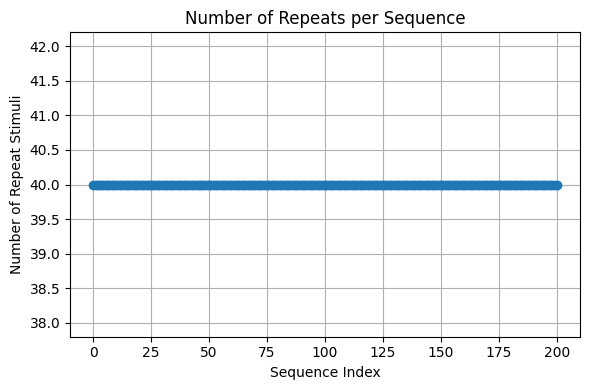

In [25]:
sm_bolivia.plot_num_repeats_per_sequence()

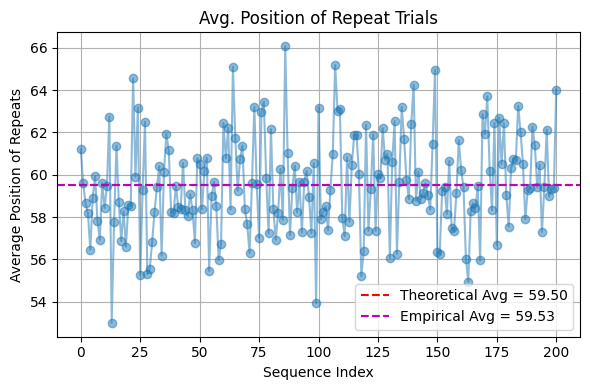

In [26]:
sm_bolivia.plot_avg_position_of_repeats()

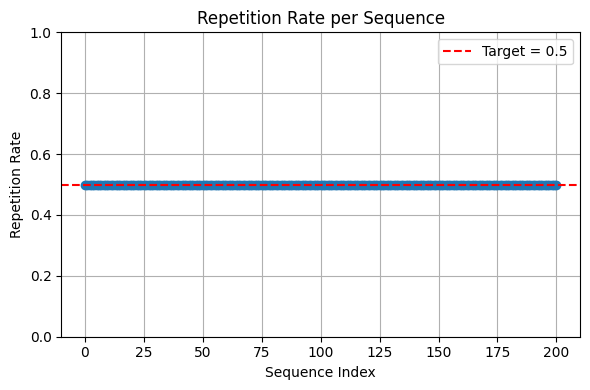

In [27]:
sm_bolivia.plot_repetition_rate_per_sequence()

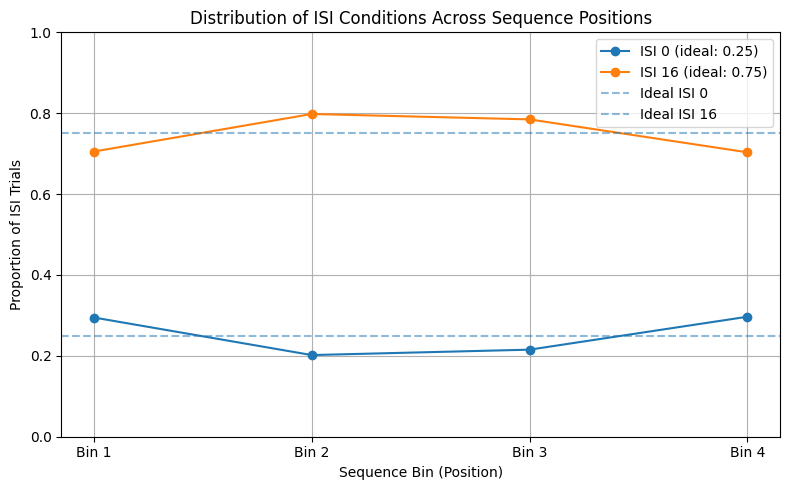

In [9]:
sm_bolivia.plot_isi_position_bias(); # to edit -- values across ISI conditions should add up to one

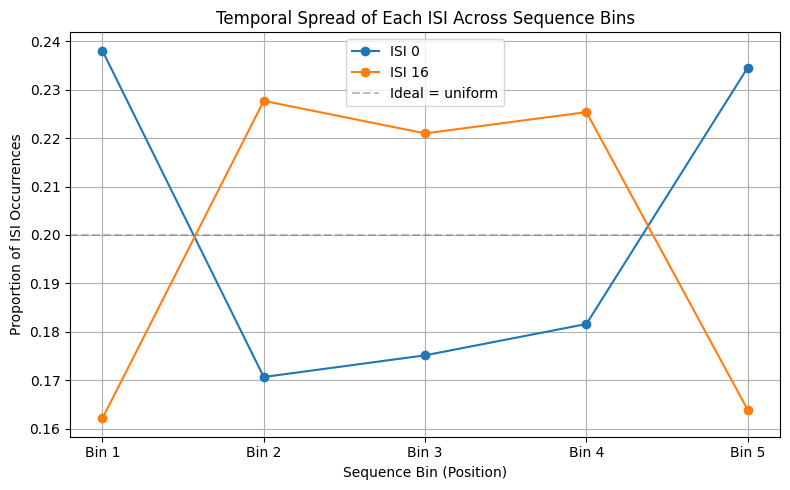

In [10]:
sm_bolivia.plot_isi_temporal_spread() # to edit -- Y values for a given curve should add up to one, and ideally as 
# close to uniform as possible

In [28]:
class StimulusManager:
    def __init__(self, stimulus_ids, isi_values, length=258, seed=5, shuffle=True):
        self._rng = random.Random(seed)
        self.stimulus_ids = list(stimulus_ids)

        self.stimulus_ids = self.stimulus_ids[:length//3*2]
        if shuffle:
            self._rng.shuffle(self.stimulus_ids)
        self.n = length
        self.isi_values = sorted(isi_values)
        self.seq_index = 0
        self.assignment_log = []
        self.debug = False
        self.stimulus_rotation_step = 10#self.n // (3 * (len(self.isi_values) - 1))  # exclude -1
        self.stimulus_offset = 0
        self.assignments = []
        self.seqs = []
        self.seed = seed

    def toggle_debug(self):
        self.debug = not self.debug
        print(f"Debug switch now turned {self.debug}!")

    def get_assignments_from_pairs(self, pairs_by_isi, seq=None):
        """
        Assign stimuli deterministically to ISI conditions using rotation and pair counts.
        """
        assignments = [-1] * self.n
        assignment_log = {}

        # Roll stimulus list by offset based on sequence number
        rolled = np.roll(self.stimulus_ids, -self.stimulus_offset)#np.roll(self.stimulus_ids, -sum(len(log) for log in self.assignment_log))
        pointer = 0
        self.stimulus_offset = (self.stimulus_offset + self.stimulus_rotation_step) % len(self.stimulus_ids)
        
        # Track which indices are already assigned
        for isi in sorted(pairs_by_isi):
            
            entries = pairs_by_isi[isi]
            
            if self.debug:
                print(isi, entries)
                print("\n")

            self._rng.shuffle(entries)
            
            for item in entries:
                stim = rolled[pointer]
                pointer += 1

                if isinstance(item, tuple):  # Repeat trial (i1, i2)
                    i1, i2 = item
                    assignments[i1] = stim
                    assignments[i2] = stim
                    assignment_log[stim] = {'isi': isi, 'type': 'repeat', 'pos': i2}
                else:  # Non-repeat trial (just one index)
                    i = item
                    assignments[i] = stim
                    assignment_log[stim] = {'isi': isi, 'type': 'nonrepeat'}
                
        if any(a == -1 for a in assignments):
            raise RuntimeError("Unassigned positions remain.")

        assignment_log = dict(sorted(assignment_log.items()))

        self.assignment_log.append(assignment_log)
        self.assignments.append(assignments)
        self.seqs.append(seq)
        self.seq_index += 1
        return assignments
    
    def save_current_assignments(self, isi_key, repetition_rate, getAnswerKey=None):
        """
        Save the current assignment info from the last sequence generation.
        - seq: The output of get_assignments_from_pairs()
        - isi_key: List of ISIs for each position (len = self.n)
        - repetition_rate: Float indicating how many repeats per total
        - getAnswerKey: Optional function to get answer key from sequence
        """
    
        last_log = self.assignment_log[-1]
    
        # Map stimulus index to filename
        stim_id_to_filename = {i: stim for i, stim in enumerate(self.stimulus_ids)}
    
        # Reconstruct filenames for current sequence
        seq_filenames = [stim_id_to_filename[s] if s in stim_id_to_filename else None for s in seq]
    
        # YouTube IDs, assuming filenames contain them
        yt_ids = [f.split("_")[-1].replace(".wav", "") if f else None for f in seq_filenames]
    
        data = {
            "repetition_rate": repetition_rate,
            "order": seq,
            "filenames_order": seq_filenames,
            "yt_id": yt_ids,
            "isi": isi_key,
            "key": getAnswerKey(seq) if getAnswerKey else None,
        }
    
        return data

    def save_sequence_to_json(self, assignments, seq, index, tol, base_path, sound_types_json, prefix="exemplar"):
        filenames_order = assignments
        isi = seq
        key = self._compute_answer_key(filenames_order)
    
        isi_counts = dict(Counter(isi))
        isi_counts_str_keys = {str(k): v for k, v in isi_counts.items()}
    
        def count_nonrepeats(isi_key):
            return sum(1 for x in isi_key if x == -1)
    
        def count_repeats(isi_key):
            return sum(1 for x in isi_key if x >= 0) // 2
    
        def current_repetition_rate(num_repeats, num_nonrepeats):
            return num_repeats / (num_repeats + num_nonrepeats)
    
        repetition_rate = current_repetition_rate(count_repeats(isi), count_nonrepeats(isi))
    
        # Create mapping from stim_path to type
        path_to_type = {entry['stim_path']: entry['type'] for entry in sound_types_json}
    
        # Extract types for each assigned stimulus
        types_order = [path_to_type.get(stim_path, 'unknown') for stim_path in filenames_order]
    
        data = {
            **isi_counts_str_keys,
            "repetition_rate": repetition_rate,
            "order": [int(re.search(r"mem_stim_(\d+).wav", s).group(1)) for s in filenames_order],
            "filenames_order": [f.split("/")[-1] for f in filenames_order],
            "types_order": types_order,  # NEW: list of types corresponding to filenames_order
            "isi": isi,
            "key": key
        }
    
        out_path = self._generate_filename(index=index, length=self.n, tol=tol, seed=self.seed,  base_path=base_path, prefix=prefix)
    
        with open(out_path, "w") as f:
            json.dump(data, f, indent=2)
    
        print(f"Saved sequence to: {out_path}")
        return out_path

    def _generate_filename(self, index, length, tol, seed, base_path, prefix=""):
        isi_str = self._isi_string()
        fname = f"{prefix}seq{index:03}_len{length}_s{seed}_{isi_str}.json"
        return os.path.join(base_path, fname)

    def _compute_answer_key(self, filenames_order):
        seen = set()
        key = []
        for stim in filenames_order:
            if stim in seen:
                key.append(1)
            else:
                key.append(0)
                seen.add(stim)
        return key

    def _isi_string(self):
        isi_str = "isi" + "_".join(f"{isi:.1f}".replace(".", "p") for isi in sorted(self.isi_values))
        return isi_str


    def check_isi_rotation(self):
        if len(self.assignment_log) < 2:
            print("Not enough sequences to check rotation.")
            return
    
        isi_order = sorted(self.isi_values)
        prev_log = self.assignment_log[-2]
        curr_log = self.assignment_log[-1]
        errors = []
    
        for stim, prev_info in prev_log.items():
            if stim in curr_log:
                curr_info = curr_log[stim]
                # Only check if both are repeat trials
                if prev_info['type'] == 'repeat' and curr_info['type'] == 'repeat':
                    prev_isi = prev_info['isi']
                    curr_isi = curr_info['isi']
    
                    # What ISI should come next in the cycle?
                    prev_index = isi_order.index(prev_isi)
                    expected_next_isi = isi_order[(prev_index + 1) % len(isi_order)]
    
                    if curr_isi != expected_next_isi:
                        errors.append((stim, prev_isi, curr_isi, expected_next_isi))
    
        if not errors:
            print("✅ All repeat stimuli rotated ISI correctly.")
        else:
            print("⚠️ ISI rotation mismatch found:")
            for stim, prev, curr, expected in errors:
                print(f"  Stim {stim}: was ISI {prev}, now ISI {curr}, expected ISI {expected}")

    def plot_stimulus_isi_history(self, max_stimuli=10):
        """
        Plot how ISI assignments changed over time for selected stimuli.
        Shows if ISI assignments cycle across sequences.
    
        Args:
            max_stimuli (int): Number of stimuli to visualize.
        """
        stim_to_isi_history = defaultdict(list)
    
        # Gather ISI history for each stimulus across sequences
        for seq_idx, log in enumerate(self.assignment_log):
            for stim, entry in sorted(log.items()):
                stim_to_isi_history[stim].append((seq_idx, entry['isi']))
    
        # Select up to max_stimuli for plotting
        selected_stims = list(stim_to_isi_history.keys())[:max_stimuli]
    
        # Plot
        plt.figure(figsize=(10, 5))
        for stim in selected_stims:
            points = stim_to_isi_history[stim]
            x = [seq for seq, _ in points]
            y = [isi for _, isi in points]
            plt.plot(x, y, marker='o', label=f"Stim {stim}", alpha=0.25)
    
        plt.xlabel("Sequence Index")
        plt.ylabel("Assigned ISI")
        plt.title("ISI Assignment History per Stimulus")
        plt.yticks(sorted(self.isi_values))
        plt.xticks(range(len(self.assignment_log)), rotation=-50)  # Force integer ticks
        plt.grid(True, linestyle='--', alpha=0.5)
        
        if max_stimuli <= 10:
            plt.legend(title="Stimulus ID", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def check_unique_stimuli_per_isi(self, plot=True):
        """
        Count how many unique stimuli were assigned to each ISI across all sequences.
        
        Args:
            plot (bool): Whether to show a bar plot of results.
        
        Returns:
            dict: ISI → number of unique stimuli
        """
        isi_to_stims = defaultdict(set)

        for seq_log in self.assignment_log:
            for stim, info in seq_log.items():
                isi = info['isi']
                isi_to_stims[isi].add(stim)

        isi_counts = {isi: len(stims) for isi, stims in isi_to_stims.items()}

        if plot:
            plt.figure(figsize=(6, 4))
            plt.bar([str(isi) for isi in sorted(isi_counts)], 
                    [isi_counts[isi] for isi in sorted(isi_counts)])
            plt.xlabel("ISI Value")
            plt.ylabel("Number of Unique Stimuli Assigned")
            plt.title("Unique Stimuli per ISI Across All Sequences")
            plt.grid(axis='y', linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()

        return isi_counts

    def plot_stimulus_isi_usage(self, max_stimuli=50):
        """
        Plot how many times each stimulus has been assigned to each *non-repeat* ISI.
        
        Args:
            max_stimuli (int): Max number of stimuli to display in the heatmap.
        """
        import pandas as pd
        import seaborn as sns
        import matplotlib.pyplot as plt
        from collections import defaultdict
    
        stim_isi_counts = defaultdict(lambda: defaultdict(int))
    
        # Count stimulus usage by ISI (excluding -1)
        for log in self.assignment_log:
            for stim, entry in log.items():
                isi = entry['isi']
                if isi == -1:
                    continue
                stim_isi_counts[stim][isi] += 1
    
        # Create DataFrame
        df = pd.DataFrame(stim_isi_counts).fillna(0).astype(int).T
        df = df.sort_index().iloc[:max_stimuli]  # limit rows
    
        # Sort ISI columns numerically
        df = df[sorted(df.columns)]
    
        # Plot
        plt.figure(figsize=(10, 6))
        sns.heatmap(df, annot=True, fmt='d', cmap="YlGnBu", 
                    cbar_kws={'label': 'Usage Count'}, xticklabels=True, yticklabels=True)
        plt.xlabel("ISI (excluding -1)")
        plt.ylabel("Stimulus")
        plt.title("Stimulus × ISI Usage Frequency")
        plt.xticks(rotation=0)
        #plt.yticks(rotation=0)
        plt.yticks([], [])
        plt.tight_layout()
        plt.show()

    def check_stimulus_position_distribution(self, plot=True):
        """
        Analyze the average position of each stimulus across all sequences.
        
        Args:
            plot (bool): Whether to display the position histogram.
        
        Returns:
            dict: stimulus → list of trial indices it appeared in
        """
        from collections import defaultdict
        import numpy as np
        import matplotlib.pyplot as plt
    
        stim_positions = defaultdict(list)
    
        # Reconstruct positions from assignment logs
        for seq_idx, log in enumerate(self.assignment_log):
            for i in range(self.n):  # positions in the sequence
                for stim, entry in log.items():
                    if entry['type'] == 'repeat':
                    #if entry.get('index') == i:  # optional if you've stored index
                        stim_positions[stim].append(entry['pos'])
    
        # Or, if you're reconstructing from assignments directly:
        # for seq_idx, assignments in enumerate(self.assignments):  # if stored
        #     for i, stim in enumerate(assignments):
        #         stim_positions[stim].append(i)
    
        # Compute average position for each stimulus
        stim_avg_position = {stim: np.mean(positions) for stim, positions in stim_positions.items()}
    
        if plot:
            plt.figure(figsize=(6, 4))
            plt.hist(stim_avg_position.values(), bins=self.n, color='orange', edgecolor='black')
            plt.axvline(self.n / 2, color='red', linestyle='--', label='Sequence Midpoint')
            plt.xlabel("Average Sequence Position")
            plt.ylabel("Number of Stimuli")
            plt.title("Stimulus Position Distribution Across Sequences")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()
    
        return stim_avg_position


    def plot_sound_type_counts_for_positive_isi(self, sound_types_json):
        """
        Plot a bar chart showing how many times each sound type was assigned
        to the *positive non-zero ISI* (e.g., ISI=16) across all assignment logs.
    
        Args:
            sound_types_json (list): List of dictionaries mapping stim_path to 'type'.
        """
        import matplotlib.pyplot as plt
        from collections import defaultdict
    
        # Step 1: Map stim_path → type
        path_to_type = {entry['stim_path']: entry['type'] for entry in sound_types_json}
    
        # Step 2: Find positive non-zero ISI (e.g., 16)
        valid_isi_values = [isi for isi in self.isi_values if isi > 0]
        if not valid_isi_values:
            raise ValueError("No positive non-zero ISI value found.")
        target_isi = valid_isi_values[0]  # assume only one such ISI (as in Bolivia case)
    
        # Step 3: Count sound types for that ISI
        type_counts = defaultdict(int)
        for log in self.assignment_log:
            for stim_path, info in log.items():
                if info.get('isi') == target_isi:
                    stype = path_to_type.get(stim_path, 'unknown')
                    type_counts[stype] += 1
    
        # Step 4: Plot
        plt.figure(figsize=(6, 4))
        types = sorted(type_counts.keys())
        counts = [type_counts[t] for t in types]
        print(counts)
    
        plt.bar(types, counts, color='skyblue', edgecolor='black')
        plt.xlabel("Sound Type")
        plt.ylabel("Frequency (ISI = {})".format(target_isi))
        plt.title(f"Sound Type Frequency at ISI = {target_isi}. Num. Seqs. = {len(self.assignment_log)}")
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    def plot_stimulus_usage_for_positive_isi(self):
        """
        Plot how many times each stimulus was assigned to the positive non-zero ISI
        (e.g., ISI = 16), across all assignment logs.
        """
        import matplotlib.pyplot as plt
        from collections import defaultdict
    
        # Step 1: Identify the target ISI
        valid_isi_values = [isi for isi in self.isi_values if isi > 0]
        if not valid_isi_values:
            raise ValueError("No positive ISI found.")
        target_isi = valid_isi_values[0]
    
        # Step 2: Count stimulus assignments at that ISI
        stim_counts = defaultdict(int)
    
        for log in self.assignment_log:
            for stim, info in log.items():
                if info.get('isi') == target_isi:
                    stim_counts[stim] += 1
    
        # Step 3: Sort and plot
        stim_ids = sorted(stim_counts, key=lambda k: int(''.join(filter(str.isdigit, k))))
        counts = [stim_counts[s] for s in stim_ids]

        condensed_stim_ids = [ s.split("/")[-1].split("_")[-1].split(".")[0] for s in stim_ids]
    
        plt.figure(figsize=(10, 4))
        plt.bar(condensed_stim_ids, counts, color='teal', edgecolor='black')
        plt.xticks(rotation=90, fontsize=6)
        plt.xlabel("Stimulus ID")
        plt.ylabel(f"# of ISI={target_isi} Assignments")
        plt.title(f"Stimulus Usage at ISI = {target_isi} (N={len(self.assignment_log)} sequences)")
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    def plot_repeats_by_type_per_sequence(self, sound_types_json):
        import matplotlib.pyplot as plt
        from collections import defaultdict
    
        # Map stim_path to type
        path_to_type = {entry['stim_path']: entry['type'] for entry in sound_types_json}
    
        # Collect data: sequence index → type → count
        seq_type_counts = defaultdict(lambda: defaultdict(int))
    
        for seq_idx, log in enumerate(self.assignment_log):
            for stim_path, info in log.items():
                if info.get('type') == 'repeat' and info.get('isi', -1) >= 0:
                    stype = path_to_type.get(stim_path, 'unknown')
                    seq_type_counts[seq_idx][stype] += 1
    
        # Extract all types and prepare data
        all_types = sorted({stype for counts in seq_type_counts.values() for stype in counts})
        seq_indices = sorted(seq_type_counts.keys())
        heights = {stype: [seq_type_counts[i].get(stype, 0) for i in seq_indices] for stype in all_types}
    
        # Plot
        plt.figure(figsize=(10, 5))
        bottom = [0] * len(seq_indices)
        for stype in all_types:
            plt.bar(seq_indices, heights[stype], bottom=bottom, label=stype)
            bottom = [sum(x) for x in zip(bottom, heights[stype])]
    
        plt.xlabel("Sequence Index")
        plt.ylabel("Repeat Trials per Type")
        plt.title("Repeat Trial Count per Sound Type (per Sequence)")
        plt.legend(title="Sound Type")
        plt.grid(True, axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    def plot_average_repeat_position_per_stimulus(self):
        """
        Plot the average sequence position of repeat trials (second occurrence) for each stimulus.
        Useful for detecting positional bias in how repeats are placed.
        """
        import matplotlib.pyplot as plt
        from collections import defaultdict
        import numpy as np
    
        stim_positions = defaultdict(list)
    
        # Gather all repeat positions
        for log in self.assignment_log:
            for stim, info in log.items():
                if info['type'] == 'repeat' and 'pos' in info:
                    stim_positions[stim].append(info['pos'])
    
        if not stim_positions:
            print("No repeat position data found.")
            return
    
        # Compute average position per stimulus
        stim_avg_pos = {stim: np.mean(positions) for stim, positions in stim_positions.items()}
        sorted_stims = sorted(stim_avg_pos, key=lambda s: int(''.join(filter(str.isdigit, s))))  # sort by stim number
        avg_positions = [stim_avg_pos[s] for s in sorted_stims]

        condensed_stim_ids = [ s.split("/")[-1].split("_")[-1].split(".")[0] for s in sorted_stims]

    
        # Plot
        plt.figure(figsize=(10, 4))
        plt.bar(condensed_stim_ids, avg_positions, color='slateblue', edgecolor='black')
        plt.axhline(self.n / 2, linestyle='--', color='red', label="Midpoint")
        plt.xticks(rotation=90, fontsize=6)
        plt.xlabel("Stimulus")
        plt.ylabel("Average Position of Repeat (2nd instance)")
        plt.title("Average Repeat Position per Stimulus")
        plt.legend()
        plt.tight_layout()
        plt.show()

def save_all_sequences(manager, tol, base_path, sound_types_json="", prefix="texture_vs_exemplar"):
    """
    Save all assignment/sequence pairs stored in the manager using its own save_sequence_to_json method.
    
    Args:
        manager: StimulusManagerTextureVsExemplar instance
        tol: The tolerance used when creating the sequence (used for filename)
        base_path: Directory to save JSON files
        prefix: Optional prefix for filenames
    """
    os.makedirs(base_path, exist_ok=True)

    for i, (assignments, seq) in enumerate(zip(manager.assignments, manager.seqs)):
        manager.save_sequence_to_json(
            assignments=assignments,
            seq=seq,
            index=i+1,
            tol=tol,
            sound_types_json=sound_types_json,
            base_path=base_path,
            prefix=prefix
        )

In [29]:
import re


path_dict = {"nhs-region": f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{stim_type}-n_80/",
             "global-music": f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{stim_type}-2025-n_80/",
             "atexts": f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_{stim_type}_2025/",
             "ind-nature": f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_{stim_type}_2025/"}



path = path_dict[stim_type]

print(path)

def numeric_sort(file_list):
    return sorted(file_list, key=lambda x: int(re.search(r'mem_stim_(\d+)\.wav', x).group(1)))

all_sounds = numeric_sort(glob.glob(path+"*wav")) 

/mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/


In [30]:
sm = StimulusManager(all_sounds, isi_values=[-1,0,16] , length=len_exp, seed=seed, shuffle=False)

for j in range(n_exps):

    seq, pairs = sm_bolivia.get_sequence_and_isi_pairings(j)

    sm.get_assignments_from_pairs(pairs, seq=seq)

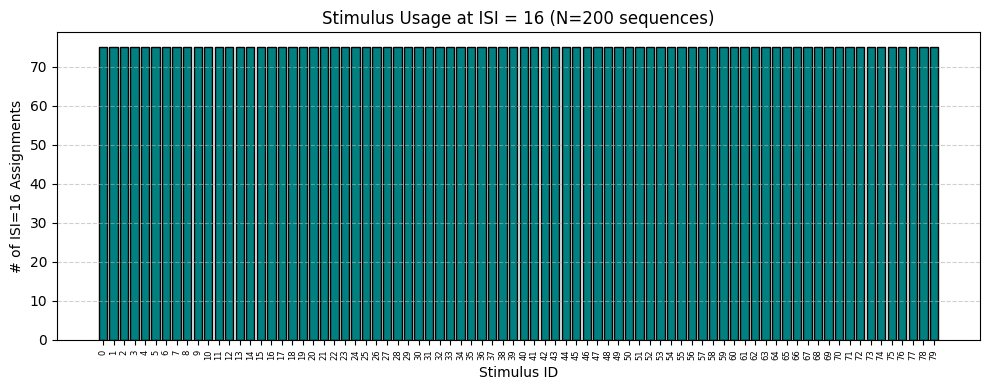

In [31]:
sm.plot_stimulus_usage_for_positive_isi()

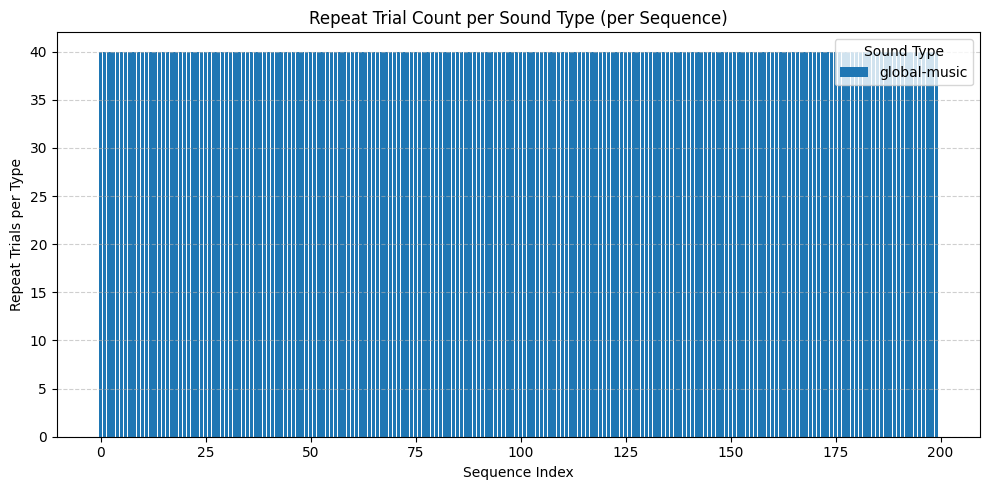

In [32]:

with open(path + "filenames.json") as f:
    sound_types_json = json.load(f)
    
sm.plot_repeats_by_type_per_sequence(sound_types_json)


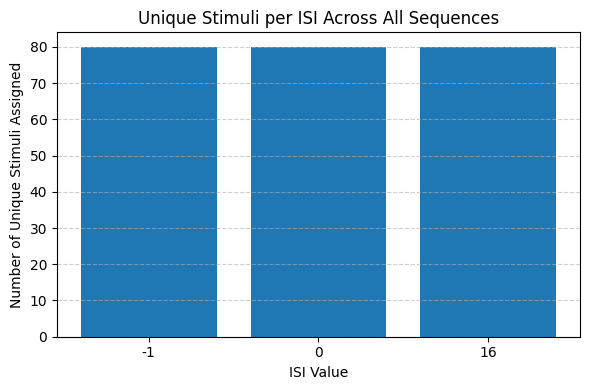

In [33]:
sm.check_unique_stimuli_per_isi();

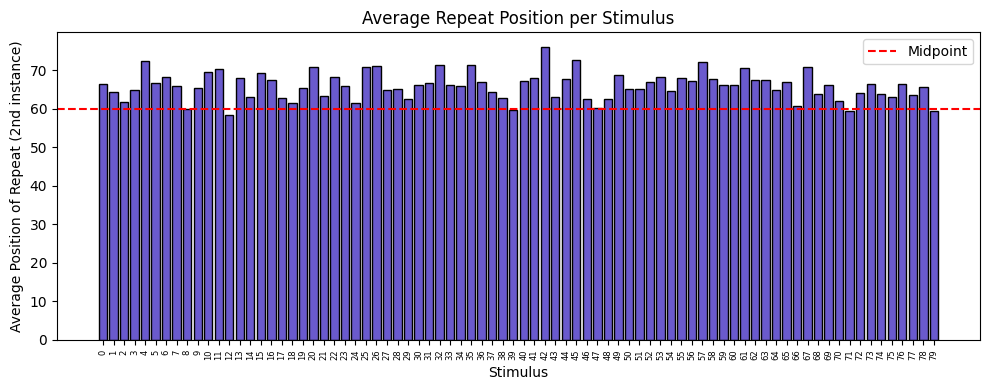

In [34]:
sm.plot_average_repeat_position_per_stimulus()

[6000]


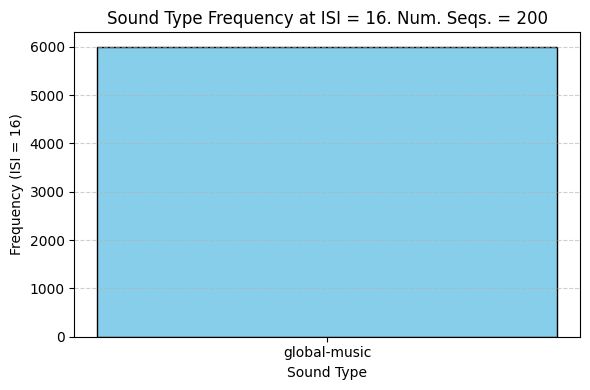

In [35]:
sm.plot_sound_type_counts_for_positive_isi(sound_types_json)

In [36]:
import os
import json
import stat
save_all_sequences(sm, 
                   0,
                   base_path=f"{path}sequences/isi_16/len{len_exp}_nonmusicians", 
                   sound_types_json=sound_types_json,
                   prefix="")

seqs_path = f"{path}sequences/isi_16/len{len_exp}_nonmusicians"
mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/glob-music/results/glob-music/len{len_exp}_nonmusicians"

def initialize_sequence_tracking(sequence_dir, extension=".json"):
    """
    Initialize tracking files for unused and used sequences.

    Creates:
      - sequence_dir/unused/unused.json
      - sequence_dir/used/used.json

    Args:
        sequence_dir (str): Base directory where sequence JSONs and subdirs live
        extension (str): File extension to track (default: '.json')
    """
    unused_dir = os.path.join(sequence_dir, "unused")
    used_dir = os.path.join(sequence_dir, "used")

    os.makedirs(unused_dir, exist_ok=True)
    os.makedirs(used_dir, exist_ok=True)

    # List all JSON sequence files in the base directory (not inside used/ or unused/)
    all_sequences = sorted([
        f for f in os.listdir(sequence_dir)
        if f.endswith(extension) and os.path.isfile(os.path.join(sequence_dir, f))
    ])

    # Save to unused/unused.json
    unused_path = os.path.join(unused_dir, "unused.json")
    with open(unused_path, "w") as f:
        json.dump(all_sequences, f, indent=2)
    print(f"✅ Created unused.json with {len(all_sequences)} sequences.")

    # Save to used/used.json (empty)
    used_path = os.path.join(used_dir, "used.json")
    with open(used_path, "w") as f:
        json.dump([], f, indent=2)
    print(f"✅ Created used.json (empty).")

initialize_sequence_tracking(seqs_path)

def create_and_chmod_dirs(full_path):
    # Create directories if they don't exist
    os.makedirs(full_path, exist_ok=False)

    # Get the final two directories in the path
    full_path = os.path.abspath(full_path)
    final2 = full_path
    final1 = os.path.dirname(final2)

    # Apply chmod 777 (read/write/execute for everyone)
    os.chmod(final1, stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)
    os.chmod(final2, stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)

# Example usage
create_and_chmod_dirs(mindhive_results_path)

Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/isi_16/len120_nonmusicians/seq001_len120_s2_isi-1p0_0p0_16p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/isi_16/len120_nonmusicians/seq002_len120_s2_isi-1p0_0p0_16p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/isi_16/len120_nonmusicians/seq003_len120_s2_isi-1p0_0p0_16p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/isi_16/len120_nonmusicians/seq004_len120_s2_isi-1p0_0p0_16p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/isi_16/len120_nonmusicians/seq005_len120_s2_isi-1p0_0p0_16p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/isi_16/len120_nonmusicians/seq006_len120_s2_isi-1p0_0p0_16p0.json
Saved sequ

In [21]:
path_to_type = {entry['stim_path']: entry['type'] for entry in sound_types_json}